# Analisi Prodotti - Azienda C

## 1. Web Scraping e Raccolta Dati
In questa prima fase, effettuiamo il web scraping del catalogo online dell'Azienda C. 
L'obiettivo è estrarre le informazioni chiave per ogni prodotto presente nella pagina mirata. Nello specifico, isoliamo:
* **Nome del prodotto** (Scarpa)
* **Categoria** di appartenenza
* **Prezzo reale** (di listino)
* **Prezzo scontato** (se presente)
* **Materiale** I dati vengono immagazzinati in liste separate per essere successivamente trasformati in un formato tabellare.

In [2]:
from Library import *
load_dotenv()
URL_C = os.getenv("URL_C")

Lista_scarpe_C = [] 
Prezzo_scarpe_C_reale = []
Prezzo_scarpe_C_sconto = []
Categoria_scarpe_C = []
Materiale_scarpe_C = []

response_C = requests.get(URL_C)
html_C = response_C.text
soup_C = bs(html_C)
    
card_prodotto_C = soup_C.find_all("div", attrs={"data-testid": "productListItem"})

for card in card_prodotto_C:
    nome_prodotto_C = card.find("span", attrs={"data-testid": "productListName"})
    if nome_prodotto_C:
        nome_C = nome_prodotto_C.get_text(strip=True)
    else:
        nome_C = "Non trovato"

    materiale_C = card.find_all("p")[0].get_text(strip=True)
    categoria_C = card.find_all("p")[1].get_text(strip=True)

    prezzo_intero = card.find("span", attrs={"class": "was-price"})
    if prezzo_intero:
        prezzo_C_no = prezzo_intero.get_text(strip=True)
    else:
        prezzo_C_no = card.find("div", attrs={"data-testid": "productListPrice"}).get_text(strip=True)

    prezzo_scontato = card.find("span", attrs={"class": "now-price"})
    if prezzo_scontato:
        prezzo_C_si = prezzo_scontato.get_text(strip=True)
    else:
        prezzo_C_si = "Non in sconto"
        
    Lista_scarpe_C.append(nome_C)
    Prezzo_scarpe_C_reale.append(prezzo_C_no)
    Prezzo_scarpe_C_sconto.append(prezzo_C_si)
    Materiale_scarpe_C.append(materiale_C)
    Categoria_scarpe_C.append(categoria_C)
        
    #print(f"{nome_C} | {materiale_C} | {categoria_C} | {prezzo_C_no} | {prezzo_C_si}")

print(len(Lista_scarpe_C))
print("Fine scraping")

370
Fine scraping


## 2. Data Cleaning e Formattazione
Una volta estratti i dati grezzi, li consolidiamo all'interno di un DataFrame **Pandas** per facilitarne la manipolazione. 

**Operazioni di pulizia effettuate:**
* Rimozione del simbolo della valuta ("€") e degli spazi vuoti dai campi dei prezzi.
* Conversione (casting) delle colonne dei prezzi in formato numerico a virgola mobile (`float`) per permettere le successive analisi statistiche e matematiche.

In [3]:
Dict_C = {"Scarpe":Lista_scarpe_C,"Categoria":Categoria_scarpe_C,"Prezzo reale":Prezzo_scarpe_C_reale,"Prezzo scontato":Prezzo_scarpe_C_sconto,"Materiale":Materiale_scarpe_C}
df_C = pd.DataFrame(Dict_C)
display(df_C)
print(df_C.info())
#Rimuoviamo il simbolo dell'Euro e gli eventuali spazi vuoti
df_C["Prezzo reale"] = df_C["Prezzo reale"].str.replace("€", "", regex=False).str.strip()
df_C["Prezzo scontato"] = df_C["Prezzo scontato"].str.replace("€", "", regex=False).str.strip()

#convertiamo in float
df_C["Prezzo reale"] = df_C["Prezzo reale"].astype(float)
df_C["Prezzo scontato"] = df_C["Prezzo scontato"].astype(float)

print(df_C.info())

,Scarpe,Categoria,Prezzo reale,Prezzo scontato,Materiale
0,Torhill Lo,Scarpe da uomo,€120.00,€120.00,Cola scamosciata
1,Godney Boat,Scarpe Originals da Uomo,€130.00,€130.00,Pelle marrone chiaro britannica
2,Berwick Seam,Scarpe da uomo,€85.00,€85.00,Pelle nera
3,Lockford Boat,Scarpe da uomo,€90.00,€90.00,Azzurro
4,Brantin Plain,Scarpe da uomo,€85.00,€85.00,Maglia grigia
...,...,...,...,...,...
365,Banstead Tip,Scarpe da uomo,€110.00,€88.00,Pelle nera
366,Watchet Lace,Scarpe sportive da uomo,€99.95,€79.95,Pelle nera
367,Motion Trek LO,Scarpe da uomo,€80.00,€64.00,Maglia blu scuro
368,Burchill Penny,Scarpe da uomo,€89.95,€62.95,Pelle nera


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Scarpe           370 non-null    object
 1   Categoria        370 non-null    object
 2   Prezzo reale     370 non-null    object
 3   Prezzo scontato  370 non-null    object
 4   Materiale        370 non-null    object
dtypes: object(5)
memory usage: 14.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Scarpe           370 non-null    object 
 1   Categoria        370 non-null    object 
 2   Prezzo reale     370 non-null    float64
 3   Prezzo scontato  370 non-null    float64
 4   Materiale        370 non-null    object 
dtypes: float64(2), object(3)
memory usage: 14.6+ KB
None


In [4]:
df_C["Prezzo scontato"].value_counts()

Prezzo scontato
120.00    48
130.00    35
80.00     33
110.00    29
100.00    25
90.00     19
79.95     13
160.00    13
150.00    13
85.00     12
64.00     10
140.00     9
190.00     9
63.95      8
71.95      8
88.00      7
89.00      6
89.95      5
75.00      5
60.00      5
62.95      4
230.00     4
119.00     4
112.00     3
170.00     3
74.95      3
99.95      3
129.00     3
139.00     3
59.50      2
71.96      2
50.00      2
95.00      2
69.95      2
195.00     2
76.95      1
43.49      1
104.00     1
83.30      1
63.96      1
56.00      1
70.00      1
79.96      1
99.00      1
180.00     1
210.00     1
59.95      1
83.95      1
49.95      1
59.97      1
119.20     1
Name: count, dtype: int64

## 3. Feature e Controllo Dati
Per analizzare le politiche di pricing dell'azienda, creiamo una nuova variabile booleana:
* **`In sconto`**: assume valore `True` se il prezzo scontato è inferiore al prezzo di listino, altrimenti `False`.

Successivamente, esploriamo la cardinalità e le frequenze delle variabili testuali (Scarpe, Categoria, Materiale) per identificare le referenze più comuni e individuare eventuali inconsistenze o valori anomali nei dati.

In [5]:
df_C["In sconto"] = df_C["Prezzo reale"] != df_C["Prezzo scontato"]
df_C["In sconto"].value_counts()

In sconto
False    302
True      68
Name: count, dtype: int64

In [6]:
df_C["Scarpe"].value_counts()

Scarpe
Wallabee                 20
Torhill Lo               11
Desert Trek              10
Wallabee EVO              7
Torview                   6
                         ..
Wesley Sun                1
Craft James Lo Loafer     1
Craft James Cap           1
Clarks Pro Free           1
Craftdean Cap             1
Name: count, Length: 167, dtype: int64

In [7]:
df_C["Categoria"].value_counts()

Categoria
Scarpe da uomo                   228
Scarpe sportive da uomo           57
Scarpe Originals Icon da Uomo     37
Scarpe Originals da Uomo          32
Sandali da uomo                    8
Pantofole da Uomo                  7
Sandali Sportivi da Uomo           1
Name: count, dtype: int64

In [8]:
df_C["Materiale"].value_counts()

Materiale
Pelle nera                             74
Pelle marrone chiaro                   25
Pelle marrone                          19
Pelle marrone chiaro scuro             15
Camoscio nero                          13
                                       ..
Nabuk nero                              1
Black Brush Off                         1
Brown Brush Off                         1
Pelle scamosciata verde oliva scuro     1
Maglia color sabbia                     1
Name: count, Length: 107, dtype: int64

In [9]:
df_C["Materiale"].unique()

array(['Cola scamosciata', 'Pelle marrone chiaro britannica',
       'Pelle nera', 'Azzurro', 'Maglia grigia', 'Pelle blu scuro',
       'Pelle marrone chiaro', 'Pelle marrone', 'Camoscio Sabbia Scuro',
       'Pelle scamosciata verde oliva', 'Pelle Scamosciata Blu Scuro',
       'Camoscio grigio', 'Pelle scamosciata marrone chiaro',
       'Pelle Bianca', 'Camoscio Sabbia', 'Nabuk blu scuro', 'Nero',
       "Pelle scamosciata d'acero", 'Interesse marrone', 'Camoscio verde',
       'Bianco', 'Tessile verde', 'Tela marina',
       'Combinazione della Marina', 'Tela bianca',
       'Brevetto della Marina', 'Camoscio nero', 'Pelle scamosciata kaki',
       'Pelle marrone scuro', 'Combinazione di abbronzatura',
       'Brown Perforated', 'Sabbia', "cera d'api", "Brevetto d'argento",
       'Combinazione di olive', 'Camoscio rosa', 'Smoke Grey Suede',
       'Maple Combination Print', 'Pelle foderata marrone',
       'Marrone scuro', 'Pelle marrone chiaro scuro',
       'Pelle scamosciata r

In [10]:
df_C["Materiale"].str.split().str[0].value_counts()

Materiale
Pelle           210
Camoscio         39
Combinazione     22
Nabuk            17
Nero             13
Cola              9
Maglia            8
Marina            6
cera              4
Marrone           4
Abbronzatura      3
Tela              2
Interesse         2
Oliva             2
Cachi             2
Grigio            2
Tan               2
Brevetto          2
Brown             2
Bianco            2
Maple             1
Smoke             1
acero             1
Black/Black       1
Bronze            1
Grano             1
Sabbia            1
Blue/Green        1
Leopardato        1
Stampa            1
Multicolore       1
Tessile           1
Saggio            1
Azzurro           1
Coca              1
Black             1
Blu               1
Name: count, dtype: int64

### 3.1 Standardizzazione della variabile "Materiale"
I dati grezzi del materiale sono molto frammentati e descrittivi (es. "Cola scamosciata", "Pelle marrone chiaro britannica"). 
Per rendere il dato aggregabile, estraiamo la prima parola della stringa e riclassifichiamo i materiali in un set definito di macro-categorie valide: **Pelle, Camoscio, Nabuk, Maglia, Tela**. Tutto il resto viene classificato come **"Non specificato"**.

In [11]:
df_C["Materiale_pulito"] = df_C["Materiale"].str.split().str[0]

materiali_validi = ["Pelle", "Camoscio", "Nabuk", "Maglia", "Tela"]
df_C.loc[~df_C["Materiale_pulito"].isin(materiali_validi), "Materiale_pulito"] = "Non specificato"

df_C["Materiale_pulito"].value_counts()

Materiale_pulito
Pelle              210
Non specificato     94
Camoscio            39
Nabuk               17
Maglia               8
Tela                 2
Name: count, dtype: int64

## 4. Tassonomia Comune e Deduplicazione
Dopo aver salvato una copia intermedia ed esserci assicurati che non vi siano righe duplicate, procediamo a uniformare le categorie originali del sito a una **tassonomia standard** (Macro e Micro Categoria).

Poiché il brand ha nomenclature molto generiche (es. "Scarpe da uomo"), mappiamo i valori basandoci sulla conoscenza a priori del DNA del brand, classificandoli principalmente come "Scarpe eleganti" (Stringate/Derby) o "Sneakers", per permettere futuri confronti diretti con i competitor.

In [12]:
df_C.to_csv("Azienda C.csv", index=False)
df_C.head()

,Scarpe,Categoria,Prezzo reale,Prezzo scontato,Materiale,In sconto,Materiale_pulito
0,Torhill Lo,Scarpe da uomo,120.0,120.0,Cola scamosciata,False,Non specificato
1,Godney Boat,Scarpe Originals da Uomo,130.0,130.0,Pelle marrone chiaro britannica,False,Pelle
2,Berwick Seam,Scarpe da uomo,85.0,85.0,Pelle nera,False,Pelle
3,Lockford Boat,Scarpe da uomo,90.0,90.0,Azzurro,False,Non specificato
4,Brantin Plain,Scarpe da uomo,85.0,85.0,Maglia grigia,False,Maglia


In [3]:
from Library import *
df_C = pd.read_csv("Azienda C.csv")

In [4]:
print(f"Righe prima: {len(df_C)}")
df_C = df_C.drop_duplicates()
print(f"Righe dopo deduplicazione: {len(df_C)}")

Righe prima: 370
Righe dopo deduplicazione: 370


In [5]:
# C ha categorie molto aggregate, le mappiamo alla tassonomia comune
# Nota: "Scarpe da uomo" è un contenitore generico che include stringate,
# derby, mocassini, ecc. — lo trattiamo come Scarpe eleganti per default

MACRO_MICRO_C = {"scarpe da uomo":("Scarpe eleganti","Stringate / Derby"),
"scarpe originals da uomo":("Scarpe eleganti","Stringate / Derby"),
"scarpe originals icon da uomo":("Scarpe eleganti","Stringate / Derby"),
"scarpe sportive da uomo":("Sneakers","Sneakers basse"),
"sandali da uomo":("Sandali","Sandali aperti"),
"sandali sportivi da uomo":("Sandali","Sandali sportivi"),
"pantofole da uomo":("Ciabatte & Pantofole", "Pantofole"),}

mapped = df_C["Categoria"].str.strip().str.lower().apply(lambda x: MACRO_MICRO_C.get(x, ("Altro", "Altro")))

df_C["Macro_categoria"] = mapped.apply(lambda x: x[0])
df_C["Micro_categoria"]  = mapped.apply(lambda x: x[1])

non_mappate = df_C[df_C["Macro_categoria"] == "Altro"]["Categoria"].unique()
print(f"Categorie non mappate: {non_mappate if len(non_mappate) else 'Nessuna'}")
print(df_C[["Macro_categoria", "Micro_categoria"]].value_counts())

Categorie non mappate: Nessuna
Macro_categoria       Micro_categoria  
Scarpe eleganti       Stringate / Derby    297
Sneakers              Sneakers basse        57
Sandali               Sandali aperti         8
Ciabatte & Pantofole  Pantofole              7
Sandali               Sandali sportivi       1
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribuzione dell'Assortimento
Visualizziamo la composizione del catalogo dell'Azienda C tramite grafici a barre. Questo ci permette di capire immediatamente in quali segmenti di mercato si concentra maggiormente l'offerta del brand (es. predominanza di Scarpe Eleganti rispetto alle Sneakers).

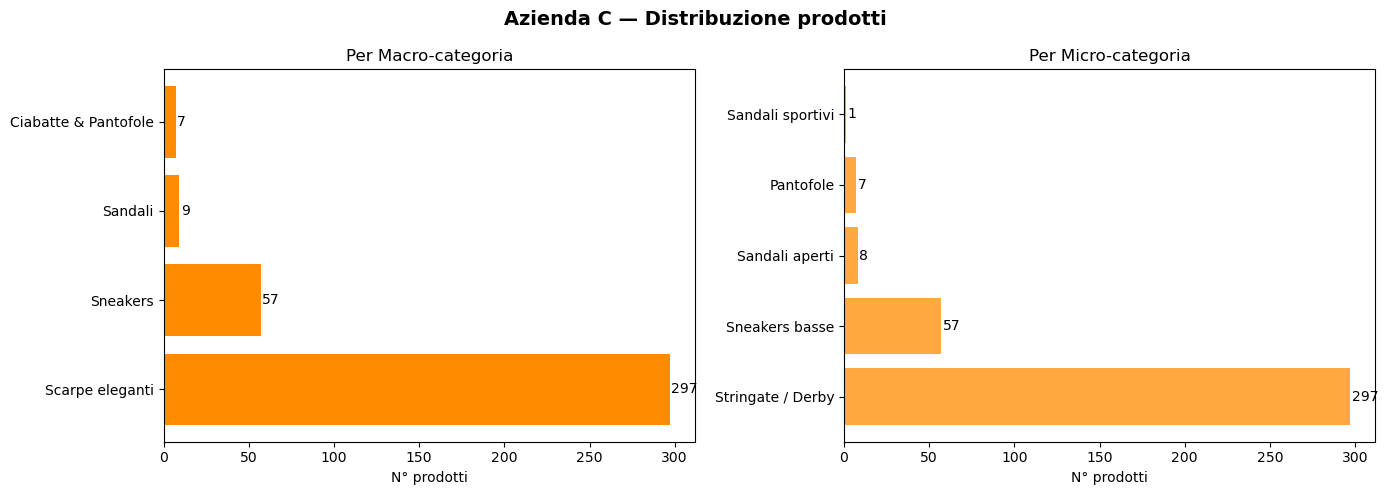

In [6]:
fig, n1 = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Azienda C — Distribuzione prodotti", fontsize=14, fontweight="bold")

macro_counts = df_C["Macro_categoria"].value_counts()
n1[0].barh(macro_counts.index, macro_counts.values, color="darkorange")
n1[0].set_title("Per Macro-categoria")
n1[0].set_xlabel("N° prodotti")
for i, v in enumerate(macro_counts.values):
    n1[0].text(v + 1, i, str(v), va="center")

micro_counts = df_C["Micro_categoria"].value_counts()
n1[1].barh(micro_counts.index, micro_counts.values, color="darkorange", alpha=0.75)
n1[1].set_title("Per Micro-categoria")
n1[1].set_xlabel("N° prodotti")
for i, v in enumerate(micro_counts.values):
    n1[1].text(v + 1, i, str(v), va="center")

plt.tight_layout()
plt.show()

### 5.2 Analisi dei Prezzi e delle Promozioni
Esaminiamo in dettaglio la strategia di sconti applicata dall'azienda. 
Calcoliamo:
* La percentuale totale di prodotti in promozione.
* Lo sconto medio assoluto (€) e relativo (%).
* La ripartizione degli sconti e il prezzo medio per ogni singola Macro-categoria.

Questa analisi ci aiuta a capire se il brand adotta una politica di prezzi premium o se spinge i volumi tramite leve promozionali aggressive.

In [16]:
# l'unico brand monomarca con sconti, merita analisi dedicata
n_tot= len(df_C)
n_sconto=df_C["In sconto"].sum()
print(f"Prodotti in sconto:{n_sconto} / {n_tot}({n_sconto/n_tot*100:.1f}%)")
print(f"Sconto medio applicato:€{(df_C['Prezzo reale'] - df_C['Prezzo scontato']).mean():.2f}")
print(f"Sconto medio %:{((df_C['Prezzo reale'] - df_C['Prezzo scontato']) / df_C['Prezzo reale'] * 100).mean():.1f}%")

print("\n=== Sconti per Macro-categoria ===")
sconto_cat = df_C.groupby("Macro_categoria").apply(
    lambda g: pd.Series({"N prodotti":len(g),
                         "In sconto":g["In sconto"].sum(),
                         "% in sconto":f"{g['In sconto'].mean()*100:.1f}%",
                         "Sconto medio €":round((g["Prezzo reale"] - g["Prezzo scontato"]).mean(), 2),})).reset_index()
print(sconto_cat.to_string(index=False))

Prodotti in sconto:68 / 370(18.4%)
Sconto medio applicato:€4.13
Sconto medio %:4.3%

=== Sconti per Macro-categoria ===
     Macro_categoria  N prodotti  In sconto % in sconto  Sconto medio €
Ciabatte & Pantofole           7          0        0.0%            0.00
             Sandali           9          0        0.0%            0.00
     Scarpe eleganti         297         51       17.2%            3.93
            Sneakers          57         17       29.8%            6.33


C:\Users\ssi106\AppData\Local\Temp\ipykernel_40592\1936941172.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sconto_cat = df_C.groupby("Macro_categoria").apply(


In [8]:
print("=== Statistiche prezzi reali ===")
print(df_C["Prezzo reale"].describe().round(2))

print("\n=== Prezzi per Macro-categoria (prezzo reale) ===")
print(df_C.groupby("Macro_categoria")["Prezzo reale"].agg(
    Media="mean", Minimo="min", Massimo="max", N="count"
).round(2))

=== Statistiche prezzi reali ===
count    370.00
mean     111.58
std       31.18
min       49.95
25%       89.24
50%      110.00
75%      130.00
max      230.00
Name: Prezzo reale, dtype: float64

=== Prezzi per Macro-categoria (prezzo reale) ===
                       Media  Minimo  Massimo    N
Macro_categoria                                   
Ciabatte & Pantofole   68.55   49.95     95.0    7
Sandali                90.99   59.95    119.0    9
Scarpe eleganti       115.84   74.95    230.0  297
Sneakers               97.94   70.00    130.0   57


### 5.3 Visualizzazione delle Dinamiche di Pricing
Utilizziamo un **istogramma** per osservare la distribuzione complessiva dei prezzi di listino, identificando la media e la presenza di eventuali "code" (prodotti particolarmente costosi o economici). 

Affianchiamo un **boxplot** raggruppato per Macro-categoria per analizzare la varianza interna ai segmenti e identificare eventuali *outlier* (prodotti premium isolati, ad esempio edizioni speciali o materiali tecnici).

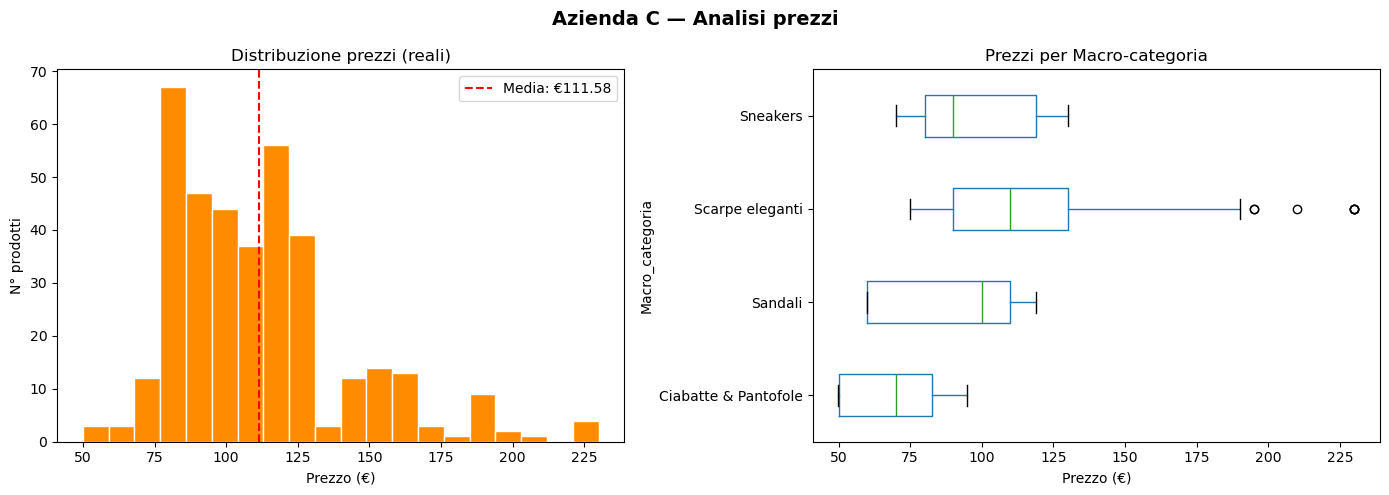

In [10]:
fig, n2 = plt.subplots(1, 2, figsize=(14, 5))


n2[0].hist(df_C["Prezzo reale"], bins=20, color="darkorange", edgecolor="white")
n2[0].axvline(df_C["Prezzo reale"].mean(), color="red", linestyle="--",
                label=f'Media: €{df_C["Prezzo reale"].mean():.2f}')
n2[0].set_title("Distribuzione prezzi (reali)")
n2[0].set_xlabel("Prezzo (€)")
n2[0].set_ylabel("N° prodotti")
n2[0].legend()

df_C.boxplot(column="Prezzo reale", by="Macro_categoria", ax=axes[1],
             grid=False, vert=False)
n2[1].set_title("Prezzi per Macro-categoria")
n2[1].set_xlabel("Prezzo (€)")
plt.suptitle("")
fig.suptitle("Azienda C — Analisi prezzi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Export del Dataset Pulito
Il processo di trasformazione è completato. Aggiungiamo un'ultima colonna identificativa (`Brand = "C"`) indispensabile per quando questo dataset verrà unito a quelli dei competitor. Salviamo il risultato nel file finale pronto per le analisi comparative.

In [11]:
df_C["Brand"] = "C"
df_C.to_csv("Azienda_C_clean.csv", index=False)
print("Azienda_C_clean.csv salvato")
print(f"Colonne:{list(df_C.columns)}")
print(f"Righe:{len(df_C)}")

Azienda_C_clean.csv salvato
Colonne:['Scarpe', 'Categoria', 'Prezzo reale', 'Prezzo scontato', 'Materiale', 'In sconto', 'Materiale_pulito', 'Macro_categoria', 'Micro_categoria', 'Brand']
Righe:370


In [13]:
df_C

,Scarpe,Categoria,Prezzo reale,Prezzo scontato,Materiale,In sconto,Materiale_pulito,Macro_categoria,Micro_categoria,Brand
0,Torhill Lo,Scarpe da uomo,120.00,120.00,Cola scamosciata,False,Non specificato,Scarpe eleganti,Stringate / Derby,C
1,Godney Boat,Scarpe Originals da Uomo,130.00,130.00,Pelle marrone chiaro britannica,False,Pelle,Scarpe eleganti,Stringate / Derby,C
2,Berwick Seam,Scarpe da uomo,85.00,85.00,Pelle nera,False,Pelle,Scarpe eleganti,Stringate / Derby,C
3,Lockford Boat,Scarpe da uomo,90.00,90.00,Azzurro,False,Non specificato,Scarpe eleganti,Stringate / Derby,C
4,Brantin Plain,Scarpe da uomo,85.00,85.00,Maglia grigia,False,Maglia,Scarpe eleganti,Stringate / Derby,C
...,...,...,...,...,...,...,...,...,...,...
365,Banstead Tip,Scarpe da uomo,110.00,88.00,Pelle nera,True,Pelle,Scarpe eleganti,Stringate / Derby,C
366,Watchet Lace,Scarpe sportive da uomo,99.95,79.95,Pelle nera,True,Pelle,Sneakers,Sneakers basse,C
367,Motion Trek LO,Scarpe da uomo,80.00,64.00,Maglia blu scuro,True,Maglia,Scarpe eleganti,Stringate / Derby,C
368,Burchill Penny,Scarpe da uomo,89.95,62.95,Pelle nera,True,Pelle,Scarpe eleganti,Stringate / Derby,C


## 6. Conclusioni e Key Takeaways (Azienda C)

Dall'analisi esplorativa del catalogo dell'Azienda C emergono evidenze molto chiare sul posizionamento e sulla strategia commerciale del brand:

* **Forte focalizzazione "Monoprodotto":** Il core business è inequivocabile. Con 297 referenze su 370 (80%), la categoria *Scarpe eleganti* rappresenta il fulcro quasi esclusivo dell'offerta.
* **Pricing lineare e sconti marginali:** La politica promozionale non è aggressiva. Solo il **18.4%** del catalogo è in saldo, con un abbattimento medio del prezzo irrisorio (**€4.13**, pari al **4.3%**). Si tratta di micro-aggiustamenti fisiologici piuttosto che di una vera strategia di svendita per fare volumi.
* **Sneakers come categoria periferica:** I modelli sportivi registrano l'incidenza di sconto più alta (**29.8%**). Trattandosi di un segmento chiaramente *non-core*, il brand utilizza con più facilità la leva del prezzo per agevolare la rotazione a magazzino.
* **Tentativi di Premiumization:** L'analisi degli *outlier* di prezzo evidenzia 3 referenze nella categoria principale con un posizionamento nettamente superiore (oltre la soglia dei 200€, come la linea Wallabee GORE-TEX), indicando la presenza di prodotti halo/premium isolati.
* **Vuoti d'offerta stagionali/casual:** I segmenti *Sandali* e *Ciabatte* sono di fatto assenti dal catalogo analizzato, lasciando un'ampia area di mercato scoperta rispetto a potenziali competitor con un'offerta più generalista.